In [12]:
import pandas as pd

df = pd.read_csv('/datasets/project_sql_result_01.csv')


In [13]:
import pandas as pd

df1 = pd.read_csv('/datasets/project_sql_result_04.csv')


In [15]:
# Ver as primeiras linhas

df.head()

# Ver as últimas linhas  
df.tail()

# Informações gerais sobre o DataFrame
df.info()

df1.head()

# Ver as últimas linhas  
df1.tail()

# Informações gerais sobre o DataFrame
df1.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [17]:

print(f"Formato: {df.shape}")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print(f"Formato: {df1.shape}")
print(f"Linhas: {df1.shape[0]}")
print(f"Colunas: {df1.shape[1]}")

Formato: (64, 2)
Linhas: 64
Colunas: 2
Formato: (94, 2)
Linhas: 94
Colunas: 2


In [19]:
df.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [20]:
df1.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [21]:

df.isnull().sum()


df.duplicated().sum()


0

In [22]:
df1.isnull().sum()


df1.duplicated().sum()


0

In [24]:
print("=== ESTUDANDO O ARQUIVO 1 ===")
print(df.head())
print(f"Formato: {df.shape}")

=== ESTUDANDO O ARQUIVO 1 ===
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
Formato: (64, 2)


In [25]:
print("=== ESTUDANDO O ARQUIVO 2 ===")
print(df1.head())
print(f"Formato: {df1.shape}")

=== ESTUDANDO O ARQUIVO 2 ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
Formato: (94, 2)


In [28]:
top_10_bairros = df1.head(10)
print("=== TOP 10 BAIRROS POR DESTINO ===")
print(top_10_bairros)

=== TOP 10 BAIRROS POR DESTINO ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


In [31]:
top_10_taxis = df.head(10)
print("=== TOP 10 EMPRESAS TAXIS ===")
print(top_10_taxis)

=== TOP 10 EMPRESAS TAXIS ===
                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


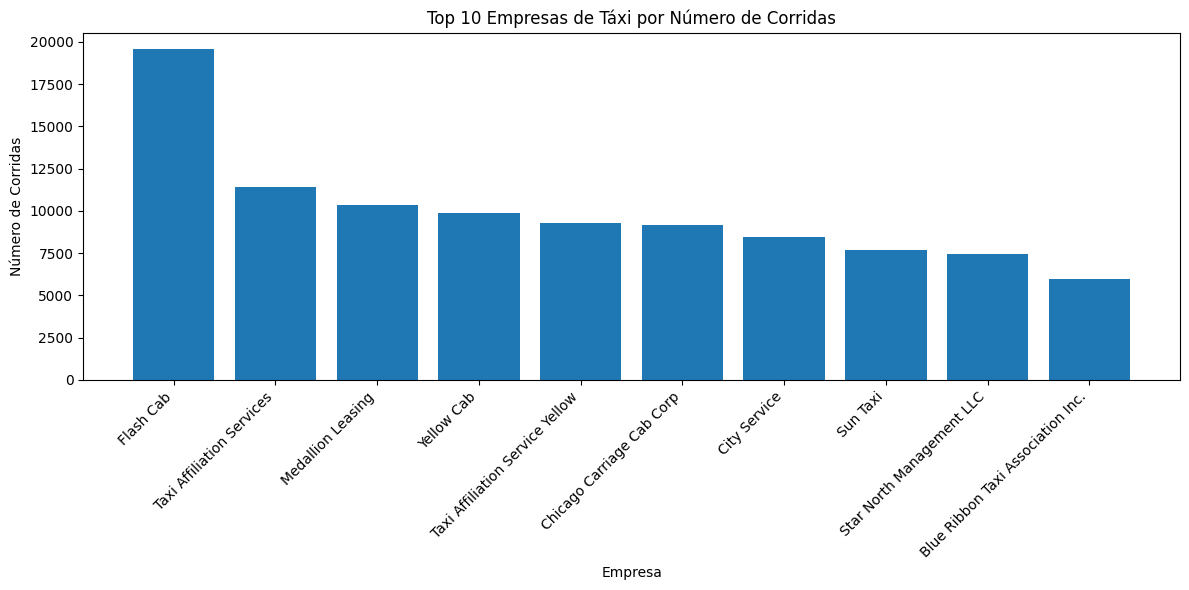

Verificando top_10_bairros:
Index(['dropoff_location_name', 'average_trips'], dtype='object')
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [44]:
import matplotlib.pyplot as plt

# Gráfico das empresas de táxi
plt.figure(figsize=(12, 6))
plt.bar(top_10_taxis['company_name'], top_10_taxis['trips_amount'])
plt.title('Top 10 Empresas de Táxi por Número de Corridas')
plt.xlabel('Empresa')
plt.ylabel('Número de Corridas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Verificando top_10_bairros:")
print(top_10_bairros.columns)
print(top_10_bairros.head())

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Dica: adicionar `round()` para melhor visualizacao dos numeros em `average_trips`

Verifica-se que a empresa que disparadamente tem mais corridas é a Flash Cab, onde a maior parte das corridas são feitas para o bairro Loop, em segundo lugar temos a empresa Taxi Affiliation, que possuí quase que a metade das corridas da Flash Cab, o segundo bairro mais visitado é o River North, que em números, se aproxima muito do Loop.

In [41]:
# Recriando o DataFrame dos bairros
top_10_bairros = df1.head(10)
print("DataFrame recriado:")
print(top_10_bairros.columns)
print(top_10_bairros.head())

DataFrame recriado:
Index(['dropoff_location_name', 'average_trips'], dtype='object')
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


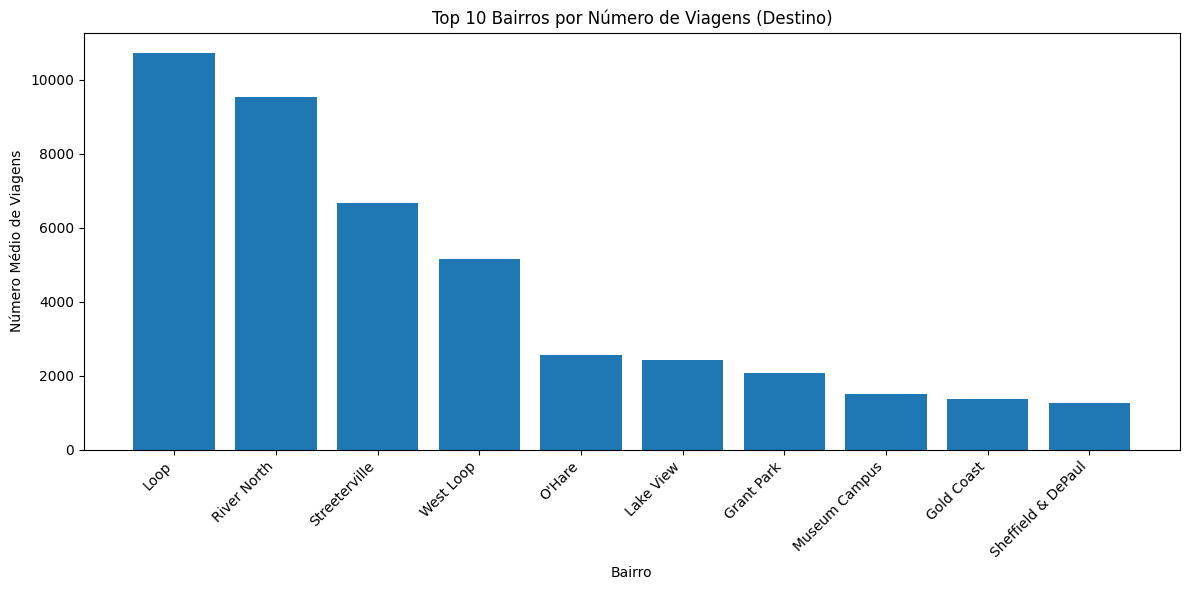

In [42]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_bairros['dropoff_location_name'], top_10_bairros['average_trips'])
plt.title('Top 10 Bairros por Número de Viagens (Destino)')
plt.xlabel('Bairro')
plt.ylabel('Número Médio de Viagens')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos entender que bairro onde tem mais corridas é o Loop, seguido do River North, são destinos que têm um padrão alto e parecido de buscar entre os usuários.

In [46]:
import pandas as pd

df7 = pd.read_csv('/datasets/project_sql_result_07.csv')



In [47]:
df7.head()

 
df7.tail()


df7.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [48]:
print(f"Formato: {df7.shape}")
print(f"Linhas: {df7.shape[0]}")
print(f"Colunas: {df7.shape[1]}")

Formato: (1068, 3)
Linhas: 1068
Colunas: 3


In [49]:
df7.describe()

,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


In [50]:
df7.isnull().sum()


df7.duplicated().sum()


197

In [52]:
df7_clean = df7.drop_duplicates()
print(f"Registros após remoção de duplicados: {df7_clean.shape[0]}")


print("Condições meteorológicas únicas:")
print(df7_clean['weather_conditions'].unique())

Registros após remoção de duplicados: 871
Condições meteorológicas únicas:
['Good' 'Bad']


In [54]:

df7_clean['start_ts'] = pd.to_datetime(df7_clean['start_ts'])


df7_clean['day_of_week'] = df7_clean['start_ts'].dt.dayofweek


print("Registros por dia da semana:")
print(df7_clean['day_of_week'].value_counts().sort_index())


sabados = df7_clean[df7_clean['day_of_week'] == 5]
print(f"\nRegistros de sábado: {len(sabados)}")

Registros por dia da semana:
5    871
Name: day_of_week, dtype: int64

Registros de sábado: 871


/tmp/ipykernel_32/1705689556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df7_clean['start_ts'] = pd.to_datetime(df7_clean['start_ts'])
/tmp/ipykernel_32/1705689556.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df7_clean['day_of_week'] = df7_clean['start_ts'].dt.dayofweek


In [55]:
tempo_bom = df7_clean[df7_clean['weather_conditions'] == 'Good']['duration_seconds']
tempo_ruim = df7_clean[df7_clean['weather_conditions'] == 'Bad']['duration_seconds']

print(f"Viagens com tempo bom: {len(tempo_bom)}")
print(f"Viagens com tempo ruim: {len(tempo_ruim)}")
print(f"Duração média - tempo bom: {tempo_bom.mean():.2f} segundos")
print(f"Duração média - tempo ruim: {tempo_ruim.mean():.2f} segundos")

Viagens com tempo bom: 723
Viagens com tempo ruim: 148
Duração média - tempo bom: 2032.25 segundos
Duração média - tempo ruim: 2409.23 segundos


In [56]:
import scipy.stats as stats
import matplotlib.pyplot as plt


print("=== TESTE DE NORMALIDADE ===")
stat_bom, p_bom = stats.shapiro(tempo_bom.sample(min(5000, len(tempo_bom))))
stat_ruim, p_ruim = stats.shapiro(tempo_ruim.sample(min(5000, len(tempo_ruim))))

print(f"Tempo bom - p-value: {p_bom:.6f}")
print(f"Tempo ruim - p-value: {p_ruim:.6f}")
print(f"Dados são normais se p-value > 0.05")

=== TESTE DE NORMALIDADE ===
Tempo bom - p-value: 0.000000
Tempo ruim - p-value: 0.020812
Dados são normais se p-value > 0.05


In [57]:
import numpy as np

def detectar_outliers_iqr(dados, nome_grupo):
    Q1 = dados.quantile(0.25)
    Q3 = dados.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]
    
    print(f"=== {nome_grupo} ===")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Número de outliers: {len(outliers)}")
    print(f"Porcentagem de outliers: {len(outliers)/len(dados)*100:.2f}%")
    
    return outliers


outliers_bom = detectar_outliers_iqr(tempo_bom, "TEMPO BOM")
outliers_ruim = detectar_outliers_iqr(tempo_ruim, "TEMPO RUIM")

=== TEMPO BOM ===
Q1: 1435.50
Q3: 2491.50
IQR: 1056.00
Limite inferior: -148.50
Limite superior: 4075.50
Número de outliers: 6
Porcentagem de outliers: 0.83%
=== TEMPO RUIM ===
Q1: 1746.00
Q3: 2940.00
IQR: 1194.00
Limite inferior: -45.00
Limite superior: 4731.00
Número de outliers: 1
Porcentagem de outliers: 0.68%


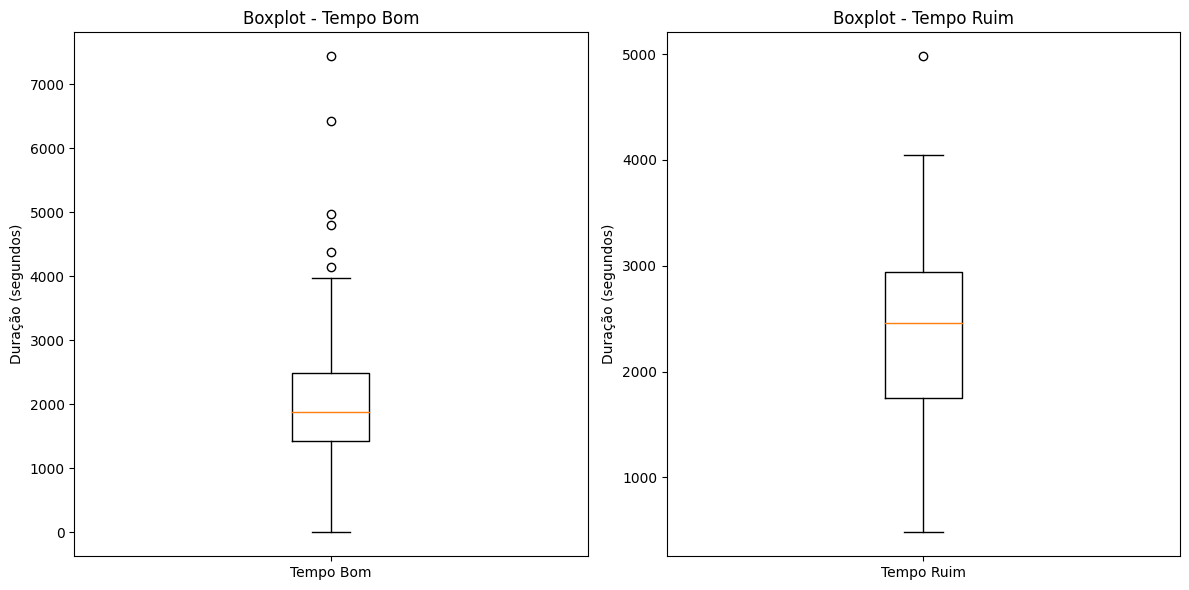

In [58]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(tempo_bom, labels=['Tempo Bom'])
plt.title('Boxplot - Tempo Bom')
plt.ylabel('Duração (segundos)')

plt.subplot(1, 2, 2)
plt.boxplot(tempo_ruim, labels=['Tempo Ruim'])
plt.title('Boxplot - Tempo Ruim')
plt.ylabel('Duração (segundos)')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
- Todas as análises e gráficos estão corretos. Parabéns!
  
- Sugestão: Adicionar comentários relevantes para análise.
</div>

In [60]:
print("=== VALORES ESPECÍFICOS DOS OUTLIERS ===")
print("\n--- TEMPO BOM ---")
print(f"Outliers encontrados: {len(outliers_bom)}")
print("Valores dos outliers (em segundos):")
for i, valor in enumerate(outliers_bom.sort_values(), 1):
    minutos = valor / 60
    print(f"  {i}. {valor:.0f} segundos ({minutos:.1f} minutos)")

print("\n--- TEMPO RUIM ---")
print(f"Outliers encontrados: {len(outliers_ruim)}")
print("Valores dos outliers (em segundos):")
for i, valor in enumerate(outliers_ruim.sort_values(), 1):
    minutos = valor / 60
    print(f"  {i}. {valor:.0f} segundos ({minutos:.1f} minutos)")

# Para contexto, vamos ver também alguns valores normais
print("\n=== PARA COMPARAÇÃO ===")
print(f"Duração média geral: {df7_clean['duration_seconds'].mean():.0f} segundos ({df7_clean['duration_seconds'].mean()/60:.1f} minutos)")
print(f"Duração mediana geral: {df7_clean['duration_seconds'].median():.0f} segundos ({df7_clean['duration_seconds'].median()/60:.1f} minutos)")

=== VALORES ESPECÍFICOS DOS OUTLIERS ===

--- TEMPO BOM ---
Outliers encontrados: 6
Valores dos outliers (em segundos):
  1. 4140 segundos (69.0 minutos)
  2. 4380 segundos (73.0 minutos)
  3. 4800 segundos (80.0 minutos)
  4. 4980 segundos (83.0 minutos)
  5. 6420 segundos (107.0 minutos)
  6. 7440 segundos (124.0 minutos)

--- TEMPO RUIM ---
Outliers encontrados: 1
Valores dos outliers (em segundos):
  1. 4980 segundos (83.0 minutos)

=== PARA COMPARAÇÃO ===
Duração média geral: 2096 segundos (34.9 minutos)
Duração mediana geral: 2015 segundos (33.6 minutos)


In [62]:

from scipy import stats as st


duracao_bom_tempo = df7_clean[df7_clean['weather_conditions'] == 'Good']['duration_seconds']
duracao_chuva = df7_clean[df7_clean['weather_conditions'] == 'Bad']['duration_seconds']


alpha = 0.05  

statistic, p_value = st.mannwhitneyu(
    duracao_bom_tempo, 
    duracao_chuva, 
    alternative='two-sided'  
)

print(f'Estatística U: {statistic}')
print(f'Valor-p: {p_value:.6f}')

if p_value < alpha:
    print("Rejeitamos a hipótese nula")
    print("Há evidência de diferença significativa nas durações")
else:
    print("Não podemos rejeitar a hipótese nula")
    print("Não há evidência suficiente de diferença significativa")

Estatística U: 37000.5
Valor-p: 0.000000
Rejeitamos a hipótese nula
Há evidência de diferença significativa nas durações


H₀ (Hipótese Nula): As distribuições das durações das viagens são iguais entre dias de bom tempo e dias chuvosos

H₁ (Hipótese Alternativa): As distribuições das durações das viagens são diferentes entre as duas condições climáticas

 O teste bilateral de Mann-Whitney U é perfeito para a análise. Visto que:

Tempo bom: 723 viagens (média: 2032.25 segundos)
Tempo ruim: 148 viagens (média: 2409.23 segundos)
Dados não são normalmente distribuídos (p-values < 0.05)

Não assume normalidade: Identificado que os dados não são normalmente distribuídos, 
compara duas amostras independentes: Duração das viagens em dias de bom tempo vs. dias chuvosos
Trabalha com medianas: Testa se as distribuições têm a mesma tendência central

Usar α = 0.05 para o teste de hipótese. Esse é realmente o nível de significância mais comum em análises estatísticas.